# Assignment 7: Creating and Reducing Mode Collapse in a GAN

## Objective

This experiment investigates mode collapse in a Generative Adversarial Network by first creating an intentionally unstable training setup and then applying a stabilising technique to improve the variety and quality of generated Fashion-MNIST images.


## 1. Libraries and Environment


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Fashion-MNIST Dataset


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)
print("Training samples:", len(dataset))


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]

Training samples: 60000


## 3. Sample Training Images


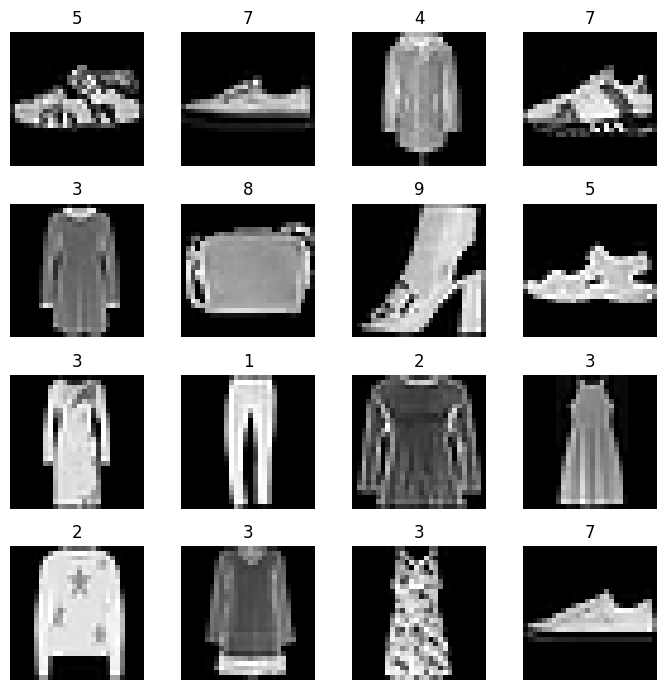

In [3]:
images, labels = next(iter(loader))
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Intentionally Unstable GAN

The first model uses a reduced generator, no batch normalisation in the generator, and an unusually high learning rate. These changes are intended to make the adversarial training unstable and increase the possibility of repeated generator outputs.


In [4]:
latent_dim = 100

class SmallGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 32, 4, 2, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

def train_gan(generator, discriminator, g_optimizer, d_optimizer, epochs, smooth_labels=False):
    criterion = nn.BCELoss()
    g_losses, d_losses, snapshots = [], [], []
    noise_fixed = torch.randn(16, latent_dim, device=device)

    for epoch in range(epochs):
        g_total, d_total = 0.0, 0.0

        for real, _ in loader:
            real = real.to(device)
            n = real.size(0)

            real_target = torch.full((n,), 0.9 if smooth_labels else 1.0, device=device)
            fake_target = torch.zeros(n, device=device)

            d_optimizer.zero_grad()
            real_pred = discriminator(real)
            d_real = criterion(real_pred, real_target)

            z = torch.randn(n, latent_dim, device=device)
            fake = generator(z)
            fake_pred = discriminator(fake.detach())
            d_fake = criterion(fake_pred, fake_target)

            d_loss = d_real + d_fake
            d_loss.backward()
            d_optimizer.step()

            g_optimizer.zero_grad()
            fake_pred = discriminator(fake)
            g_loss = criterion(fake_pred, real_target)
            g_loss.backward()
            g_optimizer.step()

            d_total += d_loss.item()
            g_total += g_loss.item()

        d_epoch = d_total / len(loader)
        g_epoch = g_total / len(loader)
        d_losses.append(d_epoch)
        g_losses.append(g_epoch)

        with torch.no_grad():
            snapshots.append(generator(noise_fixed).cpu())

        print(f"Epoch {epoch + 1:02d}/{epochs} | D Loss: {d_epoch:.4f} | G Loss: {g_epoch:.4f}")

    return g_losses, d_losses, snapshots


## 5. Training the Unstable Version


In [5]:
broken_g = SmallGenerator().to(device)
broken_d = Discriminator().to(device)

broken_g_opt = optim.Adam(broken_g.parameters(), lr=0.004, betas=(0.5, 0.999))
broken_d_opt = optim.Adam(broken_d.parameters(), lr=0.004, betas=(0.5, 0.999))

broken_g_losses, broken_d_losses, broken_snapshots = train_gan(
    broken_g, broken_d, broken_g_opt, broken_d_opt, 15, False
)


Epoch 01/15 | D Loss: 1.1253 | G Loss: 2.1784
Epoch 02/15 | D Loss: 1.1694 | G Loss: 1.4368
Epoch 03/15 | D Loss: 1.1228 | G Loss: 1.4448
Epoch 04/15 | D Loss: 1.0957 | G Loss: 1.5180
Epoch 05/15 | D Loss: 1.0723 | G Loss: 1.5617
Epoch 06/15 | D Loss: 1.0363 | G Loss: 1.6461
Epoch 07/15 | D Loss: 1.0312 | G Loss: 1.7473
Epoch 08/15 | D Loss: 0.9712 | G Loss: 1.7866
Epoch 09/15 | D Loss: 0.9606 | G Loss: 1.8597
Epoch 10/15 | D Loss: 0.9300 | G Loss: 1.9027
Epoch 11/15 | D Loss: 0.8762 | G Loss: 2.0529
Epoch 12/15 | D Loss: 0.9407 | G Loss: 1.9427
Epoch 13/15 | D Loss: 0.8677 | G Loss: 2.0913
Epoch 14/15 | D Loss: 0.8420 | G Loss: 2.2070
Epoch 15/15 | D Loss: 0.8114 | G Loss: 2.3612


## 6. Unstable Output


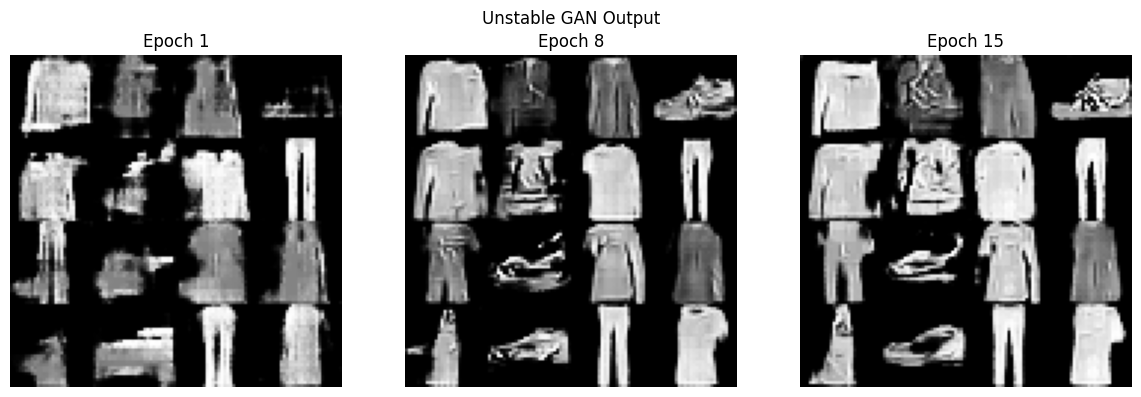

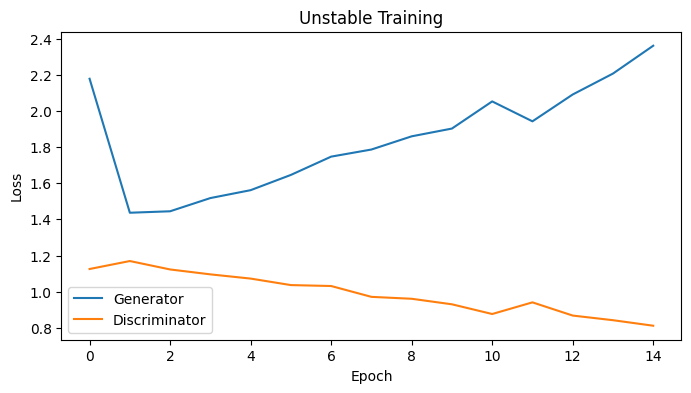

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, index in zip(axes, [0, 7, 14]):
    batch = broken_snapshots[index].squeeze().numpy()
    canvas = np.zeros((112, 112))
    for r in range(4):
        for c in range(4):
            canvas[r*28:(r+1)*28, c*28:(c+1)*28] = batch[r*4+c]
    ax.imshow(canvas, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"Epoch {index + 1}")
    ax.axis("off")
plt.suptitle("Unstable GAN Output")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(broken_g_losses, label="Generator")
plt.plot(broken_d_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Unstable Training")
plt.legend()
plt.show()


## 7. Improvement Using Label Smoothing

The second experiment keeps the same general GAN design but uses a more moderate learning rate and softens the real-class target from 1.0 to 0.9. This gives the discriminator a less extreme training target and can provide a more useful gradient to the generator.


In [7]:
improved_g = SmallGenerator().to(device)
improved_d = Discriminator().to(device)

improved_g_opt = optim.Adam(improved_g.parameters(), lr=0.001, betas=(0.5, 0.999))
improved_d_opt = optim.Adam(improved_d.parameters(), lr=0.001, betas=(0.5, 0.999))

improved_g_losses, improved_d_losses, improved_snapshots = train_gan(
    improved_g, improved_d, improved_g_opt, improved_d_opt, 15, True
)


Epoch 01/15 | D Loss: 0.8045 | G Loss: 2.2292
Epoch 02/15 | D Loss: 0.9251 | G Loss: 1.6420
Epoch 03/15 | D Loss: 1.0720 | G Loss: 1.3755
Epoch 04/15 | D Loss: 1.1300 | G Loss: 1.3014
Epoch 05/15 | D Loss: 1.1655 | G Loss: 1.2466
Epoch 06/15 | D Loss: 1.1883 | G Loss: 1.1991
Epoch 07/15 | D Loss: 1.2082 | G Loss: 1.1840
Epoch 08/15 | D Loss: 1.2132 | G Loss: 1.1665
Epoch 09/15 | D Loss: 1.2100 | G Loss: 1.1660
Epoch 10/15 | D Loss: 1.2169 | G Loss: 1.1615
Epoch 11/15 | D Loss: 1.2162 | G Loss: 1.1577
Epoch 12/15 | D Loss: 1.2162 | G Loss: 1.1609
Epoch 13/15 | D Loss: 1.2162 | G Loss: 1.1592
Epoch 14/15 | D Loss: 1.2096 | G Loss: 1.1688
Epoch 15/15 | D Loss: 1.2069 | G Loss: 1.1693


## 8. Improved Output


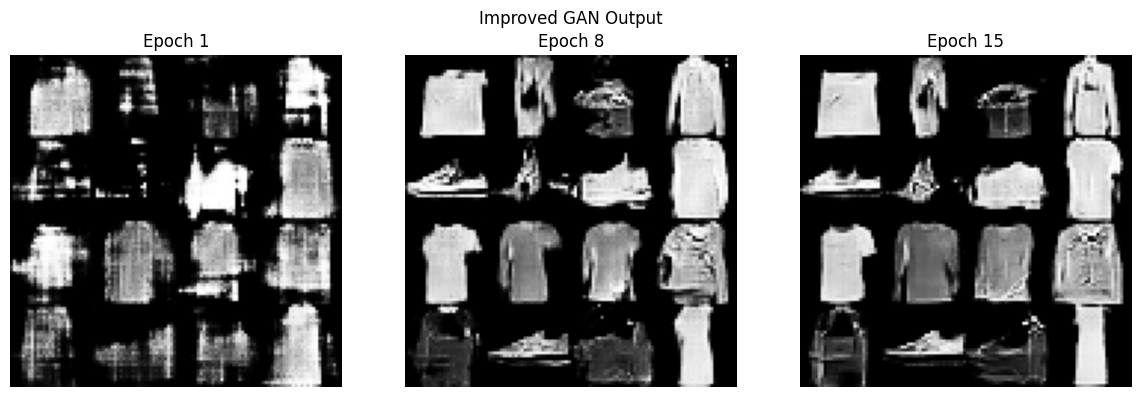

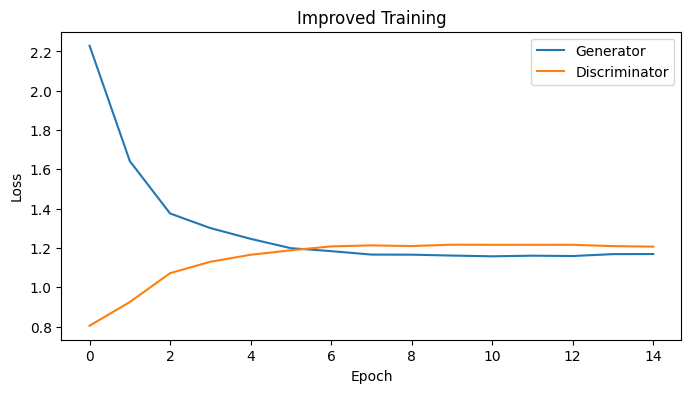

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, index in zip(axes, [0, 7, 14]):
    batch = improved_snapshots[index].squeeze().numpy()
    canvas = np.zeros((112, 112))
    for r in range(4):
        for c in range(4):
            canvas[r*28:(r+1)*28, c*28:(c+1)*28] = batch[r*4+c]
    ax.imshow(canvas, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"Epoch {index + 1}")
    ax.axis("off")
plt.suptitle("Improved GAN Output")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(improved_g_losses, label="Generator")
plt.plot(improved_d_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Training")
plt.legend()
plt.show()


## 9. Comparison and Discussion

The unstable experiment intentionally reduces the generator's capacity and uses an aggressive learning rate, making the adversarial optimisation harder. Repeated or visually similar generated samples indicate that the generator is concentrating on a limited region of the data distribution.

Label smoothing is used as the corrective technique. By changing the real target from a hard value of 1.0 to 0.9, the discriminator is discouraged from becoming excessively confident. The more moderate learning rate also gives both networks a steadier optimisation process.

The two generated-image panels should be compared for diversity. An improvement is visible when the second model produces a wider range of shapes and fewer repeated patterns than the unstable model.

## Conclusion

The experiment shows how sensitive GAN training can be to model capacity and optimisation settings. Deliberately weakening the generator and increasing the learning rate can make training unstable and encourage mode collapse. Label smoothing, together with a more controlled learning rate, provides a practical way to improve the training behaviour and increase the diversity of generated Fashion-MNIST samples.
